# CellChat

In [1]:
# install.packages("Seurat")

# # install.packages("devtools")
# BiocManager::install("BiocNeighbors")
# # devtools::install_github("hadley/devtools")

# install.packages('NMF')
# devtools::install_github("jokergoo/circlize")
# devtools::install_github("jokergoo/ComplexHeatmap")

# devtools::install_github("sqjin/CellChat")

In [2]:
# # in py console
# pip install umap-learn

https://htmlpreview.github.io/?https://github.com/sqjin/CellChat/blob/master/tutorial/CellChat-vignette.html

In [3]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(magrittr)
library(CellChat)              
library(patchwork)
library(igraph)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [4]:
# Multicore CPU usage activation - Future

library(future)

plan("multicore", workers = 10) 

options(future.globals.maxSize = 16000 * 1024^2) 

future.seed = NULL 


Attaching package: ‘future’


The following objects are masked from ‘package:igraph’:

    %->%, %<-%




In [6]:
# Load the Seurat obj

Multimodal_seurat_object <- readRDS('Seurat_Updated_Clusters.rds')

In [8]:
head(Multimodal_seurat_object@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,Sample,Group,nCount_SCT,nFeature_SCT,SCT.weight,ADT.weight,wsnn_res.1.5,seurat_clusters,celltype,CellType,CellType.Condition
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>
Group_BM_Sample_Normal BM_191125,SeuratProject,2045,114,14914,27,Normal BM,BM,314,61,0.7498349,0.2501651,5,5,Intermediate Monocytes,Classical Monocytes,Intermediate Monocytes_Normal BM
Group_BM_Sample_Normal BM_10371,SeuratProject,2073,103,24539,28,Normal BM,BM,316,53,0.5983351,0.4016649,5,5,Intermediate Monocytes,Classical Monocytes,Intermediate Monocytes_Normal BM
Group_BM_Sample_Normal BM_85418,SeuratProject,2095,130,13311,27,Normal BM,BM,308,46,0.4727930,0.5272070,9,9,Classical Monocytes,Intermediate Monocytes,Classical Monocytes_Normal BM
Group_BM_Sample_Normal BM_210224,SeuratProject,2065,131,18950,27,Normal BM,BM,312,69,0.8359615,0.1640385,5,5,Intermediate Monocytes,Classical Monocytes,Intermediate Monocytes_Normal BM
Group_BM_Sample_Normal BM_648453,SeuratProject,2417,127,23996,28,Normal BM,BM,319,73,0.5244463,0.4755537,5,5,Intermediate Monocytes,Classical Monocytes,Intermediate Monocytes_Normal BM
Group_BM_Sample_Normal BM_351513,SeuratProject,2760,154,13042,28,Normal BM,BM,315,80,0.5737341,0.4262659,5,5,Intermediate Monocytes,Classical Monocytes,Intermediate Monocytes_Normal BM


In [9]:
Idents(Multimodal_seurat_object) <- "CellType"
table(Idents(Multimodal_seurat_object))


                  BFU-E                   CFU-E                  Pro Eb 
                     26                      89                     124 
                Baso Eb                 Poly Eb                Ortho Eb 
                    274                     392                     755 
         ARG1+ Ortho Eb             Pro B-cells        Immature B-cells 
                     94                     875                    2409 
         Mature B-cells            Plasma Cells             Neutrophils 
                    260                      87                      22 
    Classical Monocytes  Intermediate Monocytes Non-classical Monocytes 
                    435                     341                      48 
               NK-cells               NKT-Cells       CD8 Naïve T-Cells 
                    202                     255                     222 
      CD4 Naïve T-Cells      CD4 Memory T-Cells              DP T-cells 
                    327                     271   

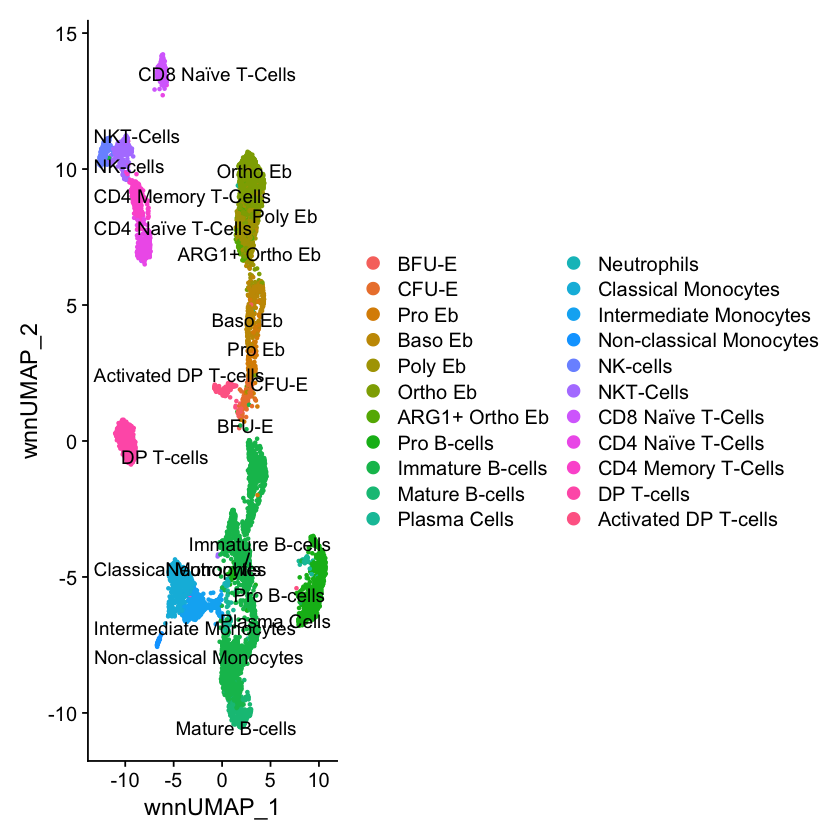

In [30]:
DimPlot(Multimodal_seurat_object, reduction = "wnn.umap", pt.size = 0.5, 
        repel=TRUE, label = TRUE,  group.by = "CellType") + 
  ggtitle(NULL)
ggsave("deeper_dimplot_celltype.jpeg", plot = last_plot(), device = "jpeg", dpi = 600, width = 12.8, height = 9)

In [10]:
CellChat <- createCellChat(Multimodal_seurat_object,
#                               group.by = 'Sample',
                              assay = 'SCT',
                              do.sparse = T)

CellChatDB <- CellChatDB.human

CellChatDB.use <- CellChatDB
CellChat@DB <- CellChatDB.use
CellChat <- subsetData(CellChat)
CellChat <- identifyOverExpressedGenes(CellChat)
CellChat <- identifyOverExpressedInteractions(CellChat)

# CellChat <- projectData(CellChat, PPI.mouse)

CellChat <- computeCommunProb(CellChat)

CellChat <- computeCommunProbPathway(CellChat)

CellChat <- aggregateNet(CellChat)

library(NMF)
library(ggalluvial)

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(Multimodal_seurat_object, assay = "SCT", do.sparse = T):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  BFU-E, CFU-E, Pro Eb, Baso Eb, Poly Eb, Ortho Eb, ARG1+ Ortho Eb, Pro B-cells, Immature B-cells, Mature B-cells, Plasma Cells, Neutrophils, Classical Monocytes, Intermediate Monocytes, Non-classical Monocytes, NK-cells, NKT-Cells, CD8 Naïve T-Cells, CD4 Naïve T-Cells, CD4 Memory T-Cells, DP T-cells, Activated DP T-cells 
The number of highly variable ligand-receptor pairs used for signaling inference is 48 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-08-29 19:15:19.319303]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-08-29 19:16:19.032135]"


Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attaching package: ‘NMF’


The following object is masked from ‘package:future’:

    run


The following object is masked from ‘package:generics’:

    fit


The following objects are masked from ‘package:igraph’:

    algorithm, compare




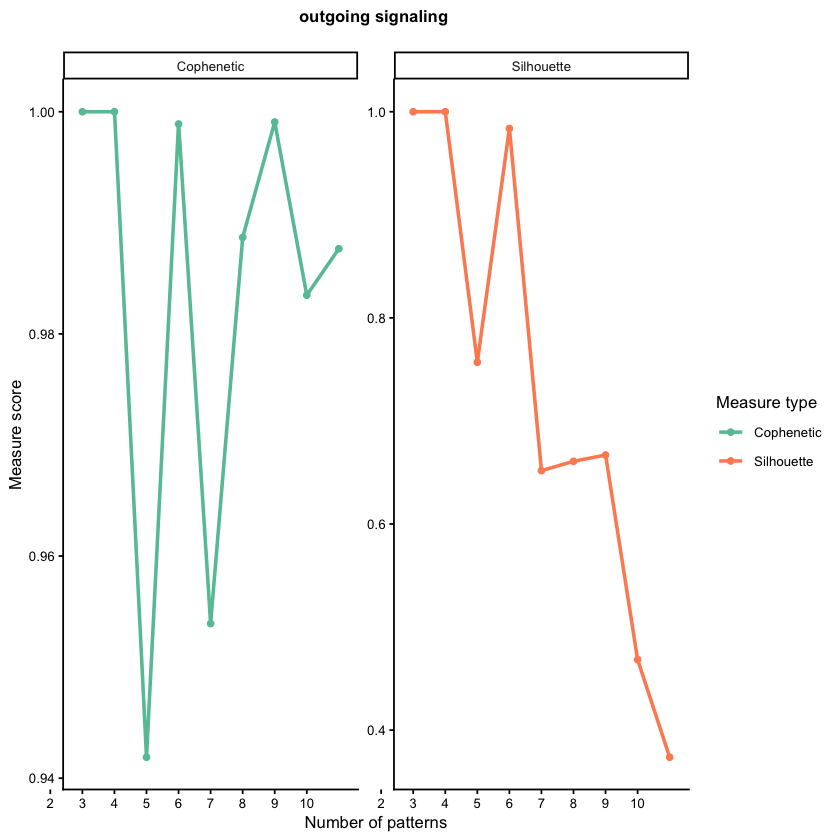

In [11]:
selectK(CellChat, pattern = "outgoing")

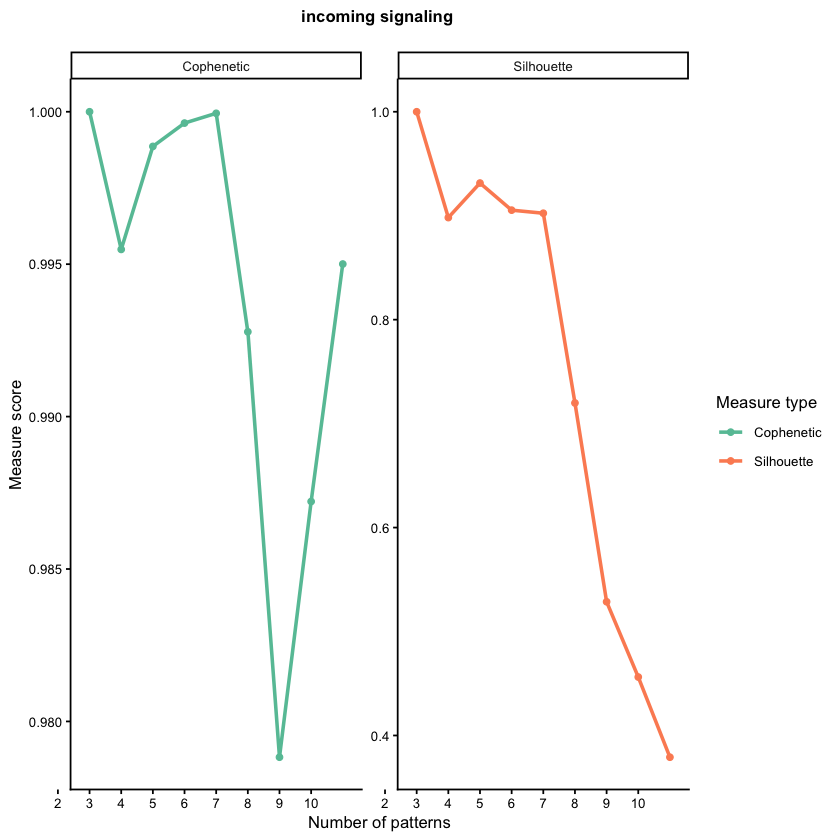

In [12]:
selectK(CellChat, pattern = "incoming")

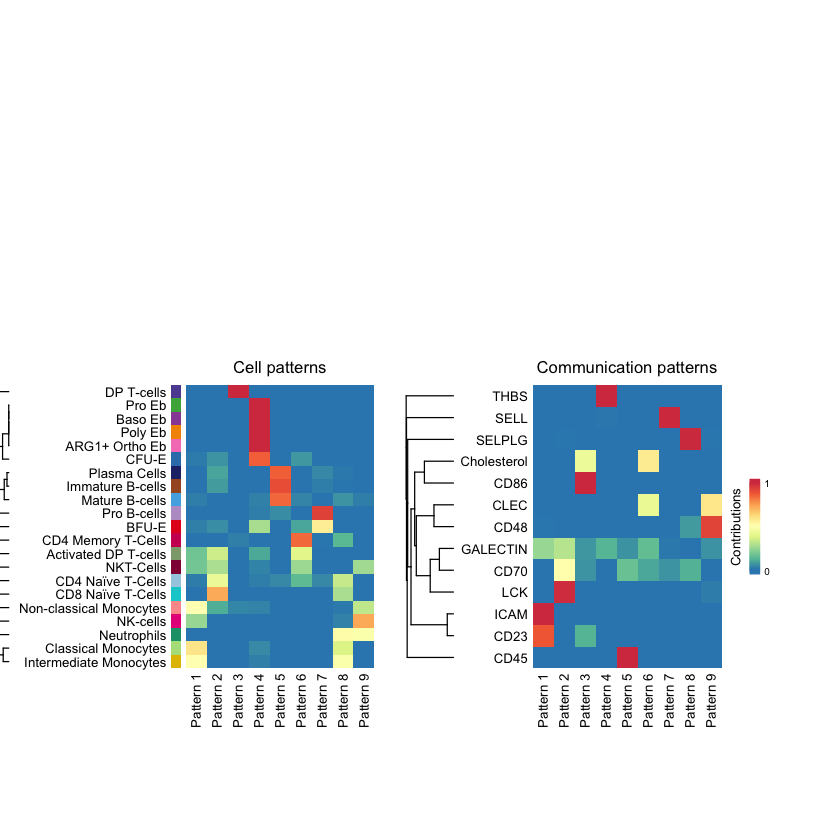

In [13]:
nPatterns = 7
CellChat <- identifyCommunicationPatterns(CellChat, 
                                          pattern = "outgoing", 
                                          k = nPatterns)
nPatterns = 9
CellChat <- identifyCommunicationPatterns(CellChat, 
                                          pattern = "incoming", 
                                          k = nPatterns)

In [14]:
library(ComplexHeatmap)

ht <- netVisual_heatmap(CellChat, measure = "count")

jpeg("Dot_Plot_nComms.jpeg", width = 17, height = 16, units = "cm", res = 600)
draw(ht, heatmap_legend_side = "right",
         annotation_legend_side = "right")
dev.off()

Loading required package: grid

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Do heatmap based on a single object 




agg_record_1230856412 
                    2

Please make sure you have load `library(ggalluvial)` when running this function



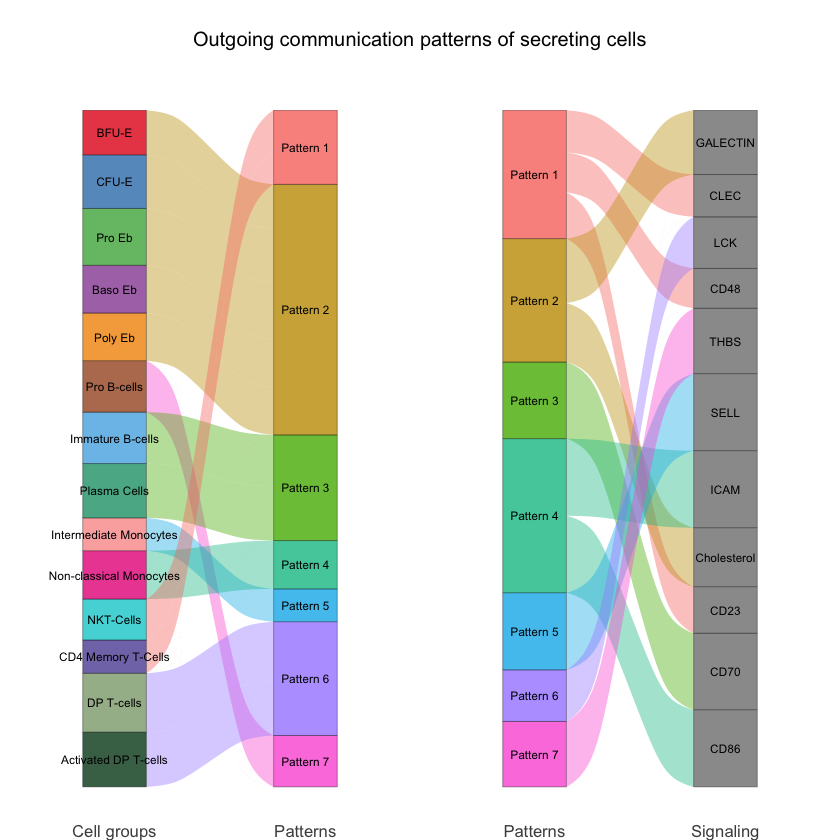

In [15]:
# river plot
netAnalysis_river(CellChat, pattern = "outgoing")
#> Please make sure you have load `library(ggalluvial)` when running this function

In [19]:
CellChat <- netAnalysis_computeCentrality(CellChat, slot.name = "netP")

In [24]:
while (!is.null(dev.list())) dev.off()

w <- 16
h <- 10
f_size <- 12 

# Incoming
jpeg("CellChat_Inc.jpg", width = w, height = h, units = "in", res = 500)
p_in <- netAnalysis_signalingRole_heatmap(CellChat, 
                                          pattern = "incoming", 
                                          width = w, 
                                          height = h, 
                                          font.size = f_size)
print(p_in)
dev.off()

# Outgoing
jpeg("CellChat_Out.jpg", width = w, height = h, units = "in", res = 500)
p_out <- netAnalysis_signalingRole_heatmap(CellChat, 
                                           pattern = "outgoing", 
                                           width = w, 
                                           height = h, 
                                           font.size = f_size)
print(p_out)
dev.off()

pdf 
  2

pdf 
  2